## CNN for Fossil Classification

In [1]:
# Import dependencies
import numpy as np 
import keras
from keras import layers
import tensorflow_datasets as tfds
from tensorflow import data as tf_data
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import random
from skimage import io
import pandas as pd

In [2]:
# You don't need this unless you are using google colab - this was to get my data to read
#from google.colab import drive
#drive.mount('/content/drive')

First, we import and split the data into testing, training, and validation sets. This should be written as a function so we can test on different folds during cross validation, where we will tune hyperparameters. 

In [22]:
# This file path will need to change
image_samples = pd.read_csv("/Users/laurathomas/Github/Paleorocks/PaleoRocks/Data/ImageSamples.csv")
header_name = 'samples'

# Takes in a list of samples (csv) and a target opb, opc, etc and returns a random sample as a string
def GetRandomThinSections(target, samplelist, num_sections, headername):
    target = str(target)

    # Filter list of samples so we only deal with those involving target
    filtered_samples = samplelist[samplelist[headername].str.contains(target)]

    n = min(num_sections, len(filtered_samples)-1)
    #randomly select one row (ie one thin section)
    if not filtered_samples.empty:
        random_thin_sections = filtered_samples.sample(n, replace = False).to_string(index=False, header=False).split('\n') # Select 1 random row
    else:
        print(f"No rows found with '{target}' in 'samples'")
    return random_thin_sections


In [23]:
#TO DO: Edit so we also get labels, wrap model in a function, write k fold CV for params
# 
#  For each opx (x = b thru f) we will hold back one total thin section and all of its related patches for testing data

# This function takes in a folder of patches and pre-determined sections to remove and splits into train, test, val data
def TrainTestValSplit(image_folder, sections):
    #image_folder = input_patches
    # randomly select a thin section (thin_section_nums)
    #thin_sections = random.sample(thin_section_nums, num_sections)
    #thin_sections = [str(ts) for ts in thin_sections]

    # Initialize empty lists
    test_data_names = []
    validation_data_names = []
    training_data_names = []
    remaining_data_names = []
    remaining_data = []
    test_data = []
    train_data = []
    val_data = []

    # Loop through targets to pull one random thin section and add to test data
    for section in sections:
        # Add thin sections corresponding to random choice to test data, then split remaining data into test and validation sets
        for filename in os.listdir(image_folder):
            if filename.lower().endswith((".jpg", ".png", ".jpeg")):
                filepath = os.path.join(image_folder, filename)
            if section in filename:
                test_data_names.append(filepath)
            else:
                remaining_data_names.append(filepath)
    # We now have the names of the files we want.
    # Now, split remaining data into training and validation sets at random
    print(test_data_names)
    random.shuffle(remaining_data_names) #randomly shuffles remaining image patches
    split = int(len(remaining_data_names) * 0.8)
    training_data_names = remaining_data_names[:split]
    validation_data_names = remaining_data_names[split:]

    # Read in images to add to data
    training_data = [io.imread(im) for im in training_data_names]
    validation_data = [io.imread(im) for im in validation_data_names]
    test_data = [io.imread(im) for im in test_data_names]

    #Stack into arrays so keras can read
    test_data = np.stack(test_data)
    validation_data = np.stack(validation_data)
    training_data = np.stack(training_data)
    return training_data, validation_data, test_data
    
augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    #layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x


In [26]:

# Change file paths depending on your data - note that fossils but not centered and center fossils are classified as being fossil posiive here
center_folder = "/Users/laurathomas/Github/Paleorocks/PaleoRocks/Data/Center_Fossil"
fossil_nocenter_folder = "/Users/laurathomas/Github/Paleorocks/PaleoRocks/Data/No_Center_Fossil"
no_fossil_folder = "/Users/laurathomas/Github/Paleorocks/PaleoRocks/Data/No_Fossil"
targets = ["opb", "opc", "opd", "ope", "opf"]
sections = []

#This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
for target in targets:
    test_sections = GetRandomThinSections(target, image_samples, 20, header_name)
    for image in test_sections:
        sections.append(image)
print("Sections Isolated for Testing:")
print(sections)
print("Number of Sections Used for Testing:")
print(len(sections))
print("Number of Sections Used in Training:")
print(83 - len(sections))

train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(fossil_nocenter_folder, sections)
train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

# Now, get label data setting fossils to 1 and no fossil to 0

Y_train = np.concatenate([np.ones(train_center.shape[0]), np.zeros(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
Y_val = np.concatenate([np.ones(val_center.shape[0]), np.zeros(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
Y_test = np.concatenate([np.ones(test_center.shape[0]), np.zeros(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

Sections Isolated for Testing:
['opb_48.4', 'opb_67.5', 'opb_76.4', 'opb_19.2', 'opb_15.4', 'opb_41.6', 'opc_18.0', ' opc_0.0', 'opc_64.1', ' opc_7.4', 'opc_39.6', 'opd_72.0', 'opd_59.0', 'opd_44.0', 'opd_89.0', 'opd_76.0', 'opd_94.0', 'opd_12.0', 'opd_26.0', 'opd_19.0', 'opd_80.0', ' opd_8.0', ' opd_0.0', 'opd_64.0', 'opd_84.0', 'opd_53.0', ' ope_39.6', ' ope_54.0', '  ope_0.0', ' ope_90.0', ' ope_70.0', ' ope_82.0', ' ope_66.0', ' ope_94.0', ' ope_62.0', ' ope_46.0', ' ope_50.0', ' ope_26.0', ' ope_37.5', ' ope_30.0', ' ope_78.0', 'ope_101.1', ' ope_18.0', ' ope_98.0', ' ope_74.0', ' ope_34.0', 'opf_85.0', 'opf_41.0', ' opf_7.0', 'opf_57.0', 'opf_85.0', 'opf_37.0', 'opf_33.0', 'opf_29.0', 'opf_97.0', ' opf_0.0', 'opf_73.0', 'opf_51.0', 'opf_11.2', ' opf_2.5', 'opf_26.0', 'opf_93.0', 'opf_81.2', 'opf_19.0', 'opf_44.9', 'opf_81.0']
Number of Sections Used for Testing:
66
Number of Sections Used in Training:
17
['/Users/laurathomas/Github/Paleorocks/PaleoRocks/Data/Center_Fossil/resized

In [27]:
# Transform numpy arrays to tf datasets

training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))


2026-04-07 16:18:29.894465: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


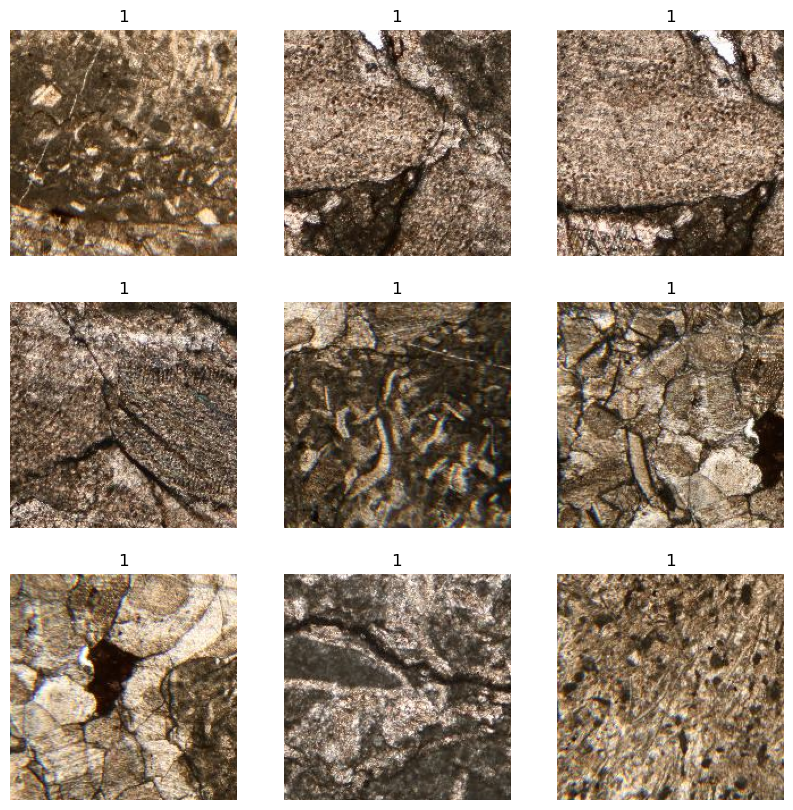

In [28]:

# Shuffle data
training_data = training_data.shuffle(len(Y_train))
validation_data = validation_data.shuffle(len(Y_val))
#testing_data = testing_data.shuffle(len(Y_test))

# Verify we did this correctly by plotting
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(testing_data.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(int(label))
    plt.axis("off")



We will use transfer learning using different pre-trained models on the imagenet dataset. We first train the Xception model. 

In [29]:
# Our images are already resized, but we could include optional resizing in the final model
# We start with data augmentation
augmentation_layers = [
    layers.RandomFlip("horizontal_and_vertical"),
    #layers.RandomRotation(0.25)
]

def data_augmentation(x):
    for layer in augmentation_layers:
        x = layer(x)
    return x

training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
)
# Create augmented data - Check with Lucy about what we want to do here
#training_data = training_data.map(lambda x, y: (data_augmentation(x), y))

nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

#aug_nonfossil_1 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
#aug_nonfossil_2 = nonfossil_train_data.map(lambda x, y: (data_augmentation(x), y))
augfossil = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
augfossil2 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
augfossil3 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))

#training_data = training_data.concatenate(aug_nonfossil_1)
training_data = training_data.concatenate(augfossil)
training_data = training_data.concatenate(augfossil2)
training_data = training_data.concatenate(augfossil3)

training_data = training_data.shuffle(1000)
#training_data = training_data.concatenate(augmented_data)

# Visualize training data with augmented data
#plt.figure(figsize=(10, 10))
#for i, (image, label) in enumerate(augmented_data.take(9)):
 #   ax = plt.subplot(3, 3, i + 1)
 #   plt.imshow(image)
 #   plt.title(int(label))
 #   plt.axis("off")
#print(augmented_data)

In [30]:
# Batch and prefetch data ?

batch_size = 36 # this could change

training_data = training_data.repeat().batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()

2026-04-07 16:18:33.489799: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-04-07 16:18:33.547700: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


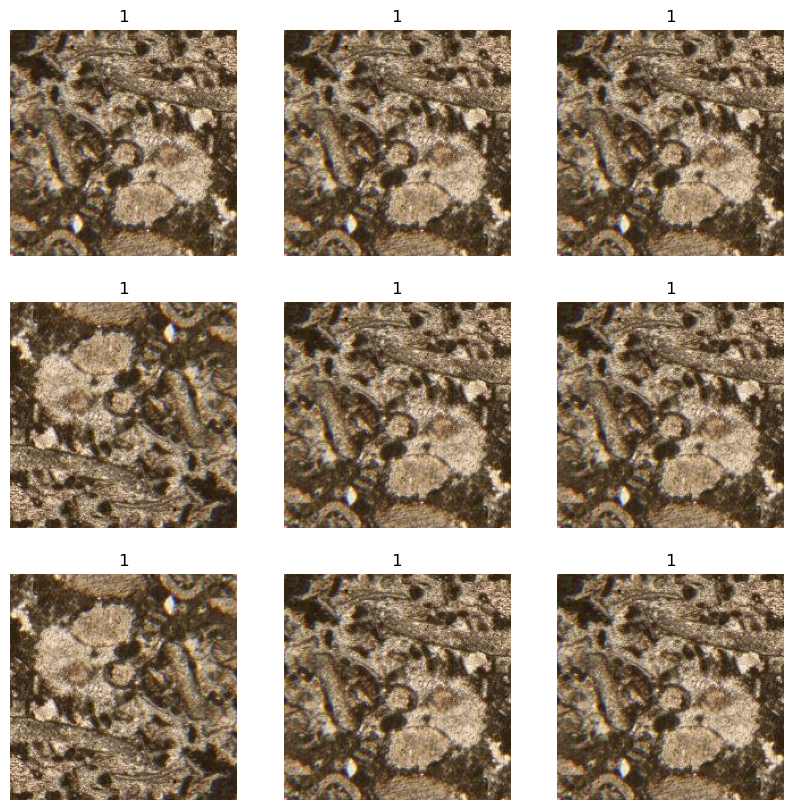

In [31]:
# Visualize augmented data

for images, labels in training_data.take(1):
    plt.figure(figsize=(10, 10))
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(np.expand_dims(first_image, 0))
        plt.imshow(np.array(augmented_image[0]).astype("int32"))
        plt.title(int(labels[0]))
        plt.axis("off")

In [32]:
# We will use transfer learning using different pre-trained models on the imagenet dataset

# Create the base model with the pre-trained imagenet weights
base_model = keras.applications.Xception(
    weights = 'imagenet',
    input_shape = (200, 200, 3),
    include_top = False) # Why do we not include imagenet at the top? 

# Freeze the base model weights (they will not be trained)

base_model.trainable = False

In [33]:
# Create a new model that goes on top of the base imagenet model
inputs = keras.Input(shape = (200, 200, 3))
# We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
scale_layer = keras.layers.Rescaling(scale = 1/127.5, offset = -1)
x = scale_layer(inputs)

# We want to keep batchnorm layers of base model in inference (predict) mode so we do not train of them. 
# Make sure that base model is running on inference mode

x = base_model(x, training = False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.1)(x)
outputs = keras.layers.Dense(1, activation = 'sigmoid')(x)
model = keras.Model(inputs, outputs)

model.summary(show_trainable = True)
# I think we should play with the layers we use here. We should try the setup they have, but maybe add more or different layers depending on how well the model does. 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [35]:
# Train the new top layer of the model
model.compile(
    optimizer = keras.optimizers.Adam(), # play with this also
    loss = keras.losses.BinaryCrossentropy(), #check this also
    metrics = [keras.metrics.BinaryAccuracy(), keras.metrics.AUC(), keras.metrics.Precision(), keras.metrics.Recall(), keras.metrics.SpecificityAtSensitivity(0.9)]
)

epochs = 10 # also play with this
print("Fitting top layer of model")
history_our_layers = model.fit(training_data, epochs = epochs, steps_per_epoch=50, validation_data = validation_data)

Fitting top layer of model
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - auc_1: 0.6729 - binary_accuracy: 0.7645 - loss: 0.5194 - precision_1: 0.5613 - recall_1: 0.0350 - specificity_at_sensitivity_1: 0.2156

KeyboardInterrupt: 

Note: I don't think two epochs was enough here. This is something we should go through with CV, plotting accuracy and loss over each iteration

In [ ]:
# Fine tune entire model
base_model.trainable = True
model.summary(show_trainable=True)

model.compile(
    optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
    loss = keras.losses.BinaryCrossentropy(),
   metrics = [keras.metrics.BinaryAccuracy(), keras.metrics.AUC(), keras.metrics.Precision, keras.metrics.Recall(), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
)

epochs = 3 #??
print("Fitting end-to-end model")
history_whole_model = model.fit(training_data, epochs = epochs, steps_per_epoch = 50, validation_data = validation_data)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,867,629 (79.60 MB)

 Trainable params: 20,809,001 (79.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 4,100 (16.02 KB)

Fitting end-to-end model
Epoch 1/3
165/165 ━━━━━━━━━━━━━━━━━━━━ 190s 810ms/step - auc_1: 0.7549 - binary_accuracy: 0.6930 - loss: 0.5860 - precision_1: 0.7284 - recall_1: 0.7236 - specificity_at_sensitivity_1: 0.4142 - val_auc_1: 0.8749 - val_binary_accuracy: 0.5895 - val_loss: 0.7131 - val_precision_1: 0.3691 - val_recall_1: 0.9713 - val_specificity_at_sensitivity_1: 0.6406
Epoch 2/3
165/165 ━━━━━━━━━━━━━━━━━━━━ 87s 530ms/step - auc_1: 0.9534 - binary_accuracy: 0.8760 - loss: 0.3347 - precision_1: 0.8625 - recall_1: 0.9272 - specificity_at_sensitivity_1: 0.8614 - val_auc_1: 0.9981 - val_binary_accuracy: 0.9151 - val_loss: 0.2753 - val_precision_1: 0.7411 - val_recall_1: 1.0000 - val_specificity_at_sensitivity_1: 1.0000
Epoch 3/3
165/165 ━━━━━━━━━━━━━━━━━━━━ 90s 545ms/step - auc_1: 0.9946 - binary_accuracy: 0.9611 - loss: 0.1962 - precision_1: 0.9512 - recall_1: 0.9811 - specificity_at_sensitivity_1: 0.9869 - val_auc_1: 1.0000 - val_binary_accuracy: 1.0000 - val_loss: 0.0960 - val_prec

In [ ]:
# Validate model on test data
print("Test dataset evaluation:")
test_eval = model.evaluate(testing_data)

Test dataset evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - auc_1: 1.0000 - binary_accuracy: 1.0000 - loss: 0.0669 - precision_1: 1.0000 - recall_1: 1.0000 - specificity_at_sensitivity_1: 1.0000


We now test on data that the model has never seen before!

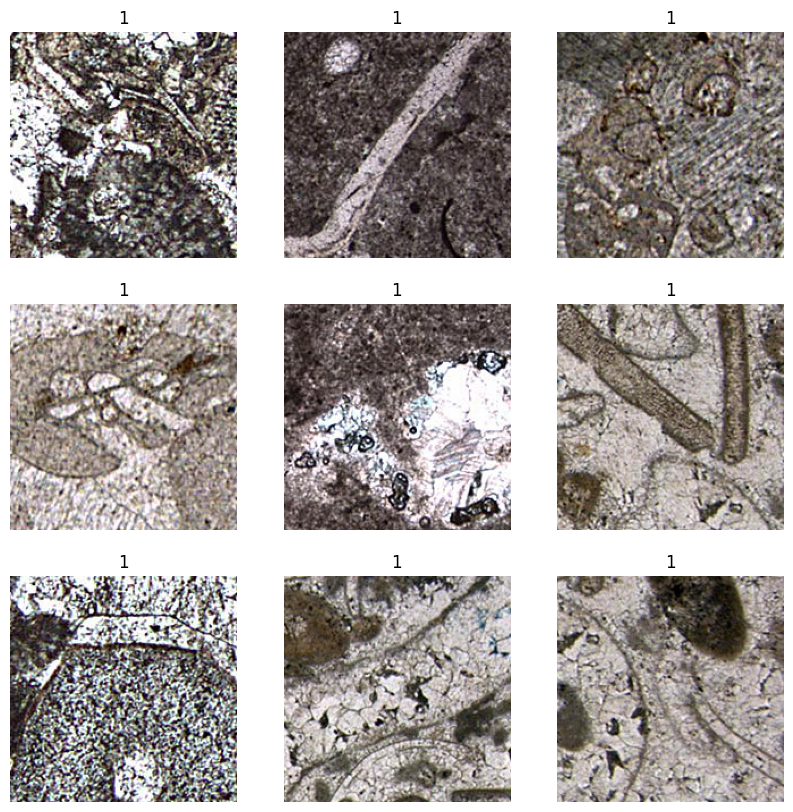

In [ ]:
# First, upload and format carbonate world data as testing data
Unseen_CenterFossil_Data_Filepath = "/Users/laurathomas/Github/Paleorocks/PaleoRocks/Data/CWfossil_center"
Unseen_EdgeFossil_Data_Filepath = "/Users/laurathomas/Github/Paleorocks/PaleoRocks/Data/CWfossil_edge"
Unseen_NonFossil_Data_Filepath = "/Users/laurathomas/Github/Paleorocks/PaleoRocks/Data/Carbonate_World_No_Fossil"

Unseen_CenterFossil_Data_Names = []
# Read images 
for filename in os.listdir(Unseen_CenterFossil_Data_Filepath):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        filepath = os.path.join(Unseen_CenterFossil_Data_Filepath, filename)
        Unseen_CenterFossil_Data_Names.append(filepath)
unseen_test_centerfossil_data = [io.imread(im) for im in Unseen_CenterFossil_Data_Names]
unseen_test_centerfossil_data = np.stack(unseen_test_centerfossil_data)

Unseen_EdgeFossil_Data_Names = []
for filename in os.listdir(Unseen_EdgeFossil_Data_Filepath):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        filepath = os.path.join(Unseen_EdgeFossil_Data_Filepath, filename)
        Unseen_EdgeFossil_Data_Names.append(filepath)
unseen_test_edgefossil_data = [io.imread(im) for im in Unseen_EdgeFossil_Data_Names]
unseen_test_edgefossil_data = np.stack(unseen_test_edgefossil_data)

Unseen_NonFossil_Data_Names = []
for filename in os.listdir(Unseen_NonFossil_Data_Filepath):
    if filename.lower().endswith((".jpg", ".png", ".jpeg")):
        filepath = os.path.join(Unseen_NonFossil_Data_Filepath, filename)
        Unseen_NonFossil_Data_Names.append(filepath)
unseen_test_nonfossil_data = [io.imread(im) for im in Unseen_NonFossil_Data_Names]
unseen_test_nonfossil_data = np.stack(unseen_test_nonfossil_data)

unseen_test_vals = np.concatenate([np.ones(unseen_test_centerfossil_data.shape[0]), np.zeros(unseen_test_edgefossil_data.shape[0]), np.zeros(unseen_test_nonfossil_data.shape[0])])
unseen_test_data = np.concatenate([unseen_test_centerfossil_data, unseen_test_edgefossil_data, unseen_test_nonfossil_data])

# Put into correct format
unseen_test_data = tf.data.Dataset.from_tensor_slices((unseen_test_data, unseen_test_vals))

# Verify via plotting
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(unseen_test_data.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(int(label))
    plt.axis("off")

# Batch
unseen_test_data = unseen_test_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()


In [ ]:
print("Unseen Test Data Evaluation:")
unseen_test_eval = model.evaluate(unseen_test_data)

Unseen Test Data Evaluation:
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - auc_1: 0.5712 - binary_accuracy: 0.5600 - loss: 0.7816 - precision_1: 0.4000 - recall_1: 0.4444 - specificity_at_sensitivity_1: 0.2500


Plotting Accuracy and Loss

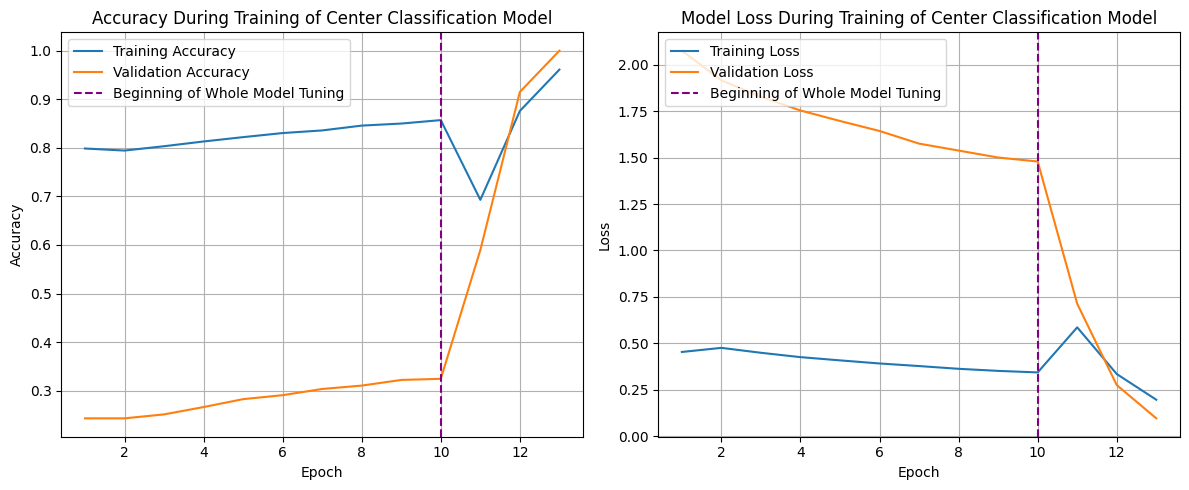

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(np.arange(1,14), np.concatenate([history_our_layers.history['binary_accuracy'], history_whole_model.history['binary_accuracy']]), label='Training Accuracy')
plt.plot(np.arange(1,14),np.concatenate([history_our_layers.history['val_binary_accuracy'],history_whole_model.history['val_binary_accuracy']]), label='Validation Accuracy')
plt.axvline(x = 10, linestyle = '--', color = 'purple', label = 'Beginning of Whole Model Tuning')
plt.title('Accuracy During Training of Center Classification Model')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.grid()
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(np.arange(1,14), np.concatenate([history_our_layers.history['loss'], history_whole_model.history['loss']]), label='Training Loss')
plt.plot(np.arange(1,14), np.concatenate([history_our_layers.history['val_loss'], history_whole_model.history['val_loss']]), label='Validation Loss')
plt.axvline(x = 10, linestyle = '--', color = 'purple', label = 'Beginning of Whole Model Tuning')
plt.title('Model Loss During Training of Center Classification Model')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.grid()
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
preds = model.predict(unseen_test_data)
predictions = np.zeros(preds.shape)
for i in range(len(preds)):
    if preds[i] >= 0.5:
        predictions[i] = 1
    else:
        predictions[i] = 0
print(predictions)
print(unseen_test_vals)

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step
[[1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


In [ ]:
i=0

for (feature, label) in nonfossil_train_data:
    i += 1
print(i)

j = 0
for (feature, label) in fossil_train_data:
    j+=1
print(j)

2598
834


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step  


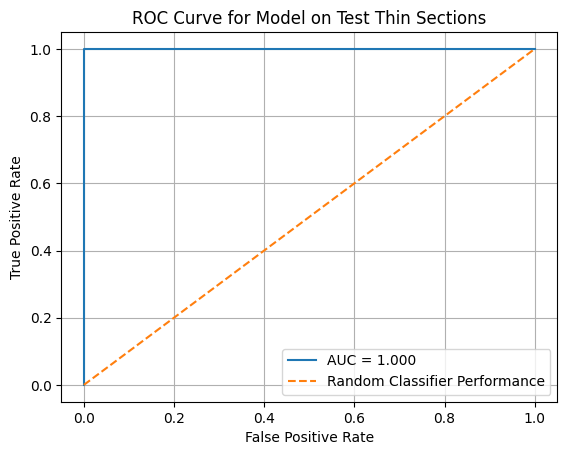

<Figure size 640x480 with 0 Axes>

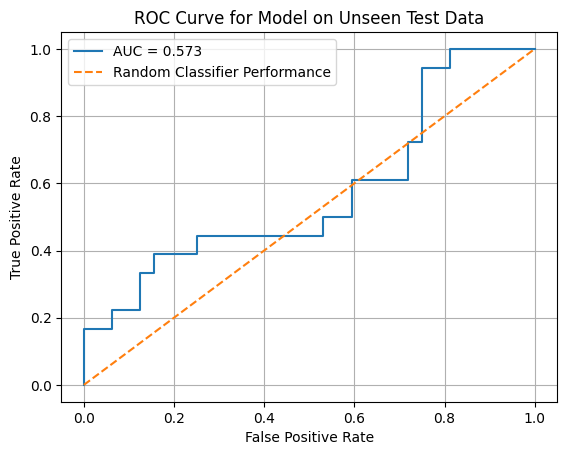

: 

In [ ]:
# ROC Curve Plot
predictions_test = model.predict(testing_data)
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(Y_test, predictions_test)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle = "--", label = "Random Classifier Performance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Model on Test Thin Sections")
plt.grid()
plt.legend()
plt.show()

plt.figure()
fpr, tpr, thresholds = roc_curve(unseen_test_vals, preds)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle = "--", label = "Random Classifier Performance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Model on Unseen Test Data")
plt.grid()
plt.legend()
plt.show()


### As an experiment, we train and test the model on different thin section test sets (randomly selected)

Iteration: 1
Sections Isolated for Testing in Iteration 1:
['opb_34.1', 'opc_39.6', 'opd_59.0', 'ope_34.0', 'opf_33.0']
['/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opc_39.6_patch4.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opd_59.0b_patch1.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opd_59.0a_patch1.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opd_59.0a_patch2.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opd_59.0c_patch1.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opd_59.0a_patch5.png', '/content/drive/MyDrive/MLGeoProject/Center_Fossil/resized_opd_59.0c_patch2.png']
['/content/drive/MyDrive/MLGeoProject/No_Center_Fossil/resized_opc_39.6_patch3.png', '/content/drive/MyDrive/MLGeoProject/No_Center_Fossil/resized_opc_39.6_patch2.png', '/content/drive/MyDrive/MLGeoProject/No_Center_Fossil/resized_opc_39.6_patch1.png', '/content/drive/MyDrive/MLGeoProject/No_Center_Fossil

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_1 (Rescaling)     │ (None, 200, 200, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 1)             │      2,049 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,863,529 (79.59 MB)

 Trainable params: 2,049 (8.00 KB)

...

 Total params: 20,867,629 (79.60 MB)

 Trainable params: 20,809,001 (79.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

 Optimizer params: 4,100 (16.02 KB)

Fitting end-to-end model iteration 5
Epoch 1/3
165/165 ━━━━━━━━━━━━━━━━━━━━ 157s 721ms/step - auc_11: 0.7630 - binary_accuracy: 0.6910 - loss: 0.5898 - precision_11: 0.7532 - recall_11: 0.6675 - specificity_at_sensitivity_11: 0.4139 - val_auc_11: 0.8797 - val_binary_accuracy: 0.5285 - val_loss: 0.8058 - val_precision_11: 0.3361 - val_recall_11: 0.9712 - val_specificity_at_sensitivity_11: 0.6498
Epoch 2/3
165/165 ━━━━━━━━━━━━━━━━━━━━ 87s 527ms/step - auc_11: 0.9557 - binary_accuracy: 0.8850 - loss: 0.3306 - precision_11: 0.8806 - recall_11: 0.9196 - specificity_at_sensitivity_11: 0.8682 - val_auc_11: 1.0000 - val_binary_accuracy: 0.8522 - val_loss: 0.3402 - val_precision_11: 0.6209 - val_recall_11: 1.0000 - val_specificity_at_sensitivity_11: 1.0000
Epoch 3/3
165/165 ━━━━━━━━━━━━━━━━━━━━ 86s 522ms/step - auc_11: 0.9963 - binary_accuracy: 0.9657 - loss: 0.1918 - precision_11: 0.9542 - recall_11: 0.9861 - specificity_at_sensitivity_11: 0.9954 - val_auc_11: 1.0000 - val_binary_accuracy: 0.9

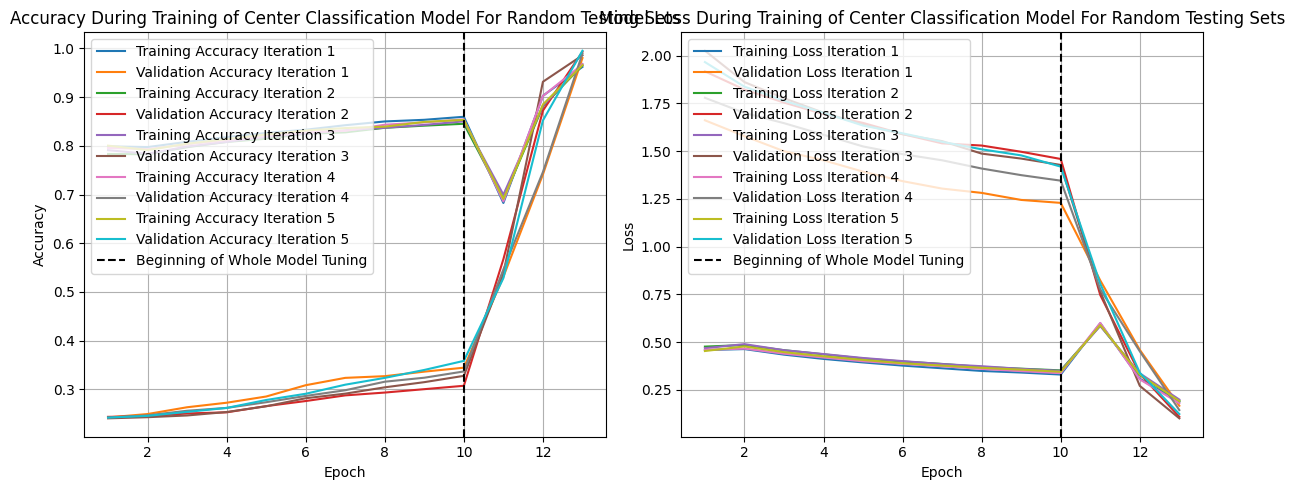

In [ ]:
center_folder = "/content/drive/MyDrive/MLGeoProject/Center_Fossil"
fossil_nocenter_folder = "/content/drive/MyDrive/MLGeoProject/No_Center_Fossil"
no_fossil_folder = "/content/drive/MyDrive/MLGeoProject/No_Fossil"
targets = ["opb", "opc", "opd", "ope", "opf"]

plt.figure(figsize=(12, 5))

for i in range(1,6):
    print(f"Iteration: {i}")
    
    sections = []

    #This randomly gets test sections for our data (they will be fixed for each run of traintestvalsplit)
    for target in targets:
        test_section = GetRandomThinSections(target, image_samples, header_name)
        sections.append(test_section)
    print(f"Sections Isolated for Testing in Iteration {i}:")
    print(sections)

    train_center, val_center, test_center = TrainTestValSplit(center_folder, sections)
    train_nocenter, val_nocenter, test_nocenter = TrainTestValSplit(fossil_nocenter_folder, sections)
    train_nofossil, val_nofossil, test_nofossil = TrainTestValSplit(no_fossil_folder, sections)

    # Now, get label data setting fossils to 1 and no fossil to 0

    Y_train = np.concatenate([np.ones(train_center.shape[0]), np.zeros(train_nocenter.shape[0]), np.zeros(train_nofossil.shape[0])])
    Y_val = np.concatenate([np.ones(val_center.shape[0]), np.zeros(val_nocenter.shape[0]), np.zeros(val_nofossil.shape[0])])
    Y_test = np.concatenate([np.ones(test_center.shape[0]), np.zeros(test_nocenter.shape[0]), np.zeros(test_nofossil.shape[0])])
    training_data = np.concatenate([train_center, train_nocenter, train_nofossil])
    validation_data = np.concatenate([val_center, val_nocenter, val_nofossil])
    testing_data = np.concatenate([test_center, test_nocenter, test_nofossil])

    # Transform numpy arrays to tf datasets

    training_data = tf.data.Dataset.from_tensor_slices((training_data, Y_train))
    validation_data = tf.data.Dataset.from_tensor_slices((validation_data, Y_val))
    testing_data = tf.data.Dataset.from_tensor_slices((testing_data, Y_test))

    # Shuffle data
    training_data = training_data.shuffle(len(Y_train))
    validation_data = validation_data.shuffle(len(Y_val))
    testing_data = testing_data.shuffle(len(Y_test))

    # Augment Data
    training_data = training_data.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
    )

    nonfossil_train_data = training_data.filter(lambda x, y: tf.equal(y,0))
    fossil_train_data = training_data.filter(lambda x, y: tf.equal(y, 1))

    augfossil = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil2 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))
    augfossil3 = fossil_train_data.map(lambda x, y: (data_augmentation(x), y))

    training_data = training_data.concatenate(augfossil)
    training_data = training_data.concatenate(augfossil2)
    training_data = training_data.concatenate(augfossil3)

    training_data = training_data.shuffle(1000)

    # Batch and prefetch data 

    batch_size = 36 # this could change

    training_data = training_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    validation_data = validation_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()
    testing_data = testing_data.batch(batch_size).prefetch(tf_data.AUTOTUNE).cache()

    # Create the base model with the pre-trained imagenet weights
    base_model = keras.applications.Xception(
        weights = 'imagenet',
        input_shape = (200, 200, 3),
        include_top = False) # Why do we not include imagenet at the top? 

    # Freeze the base model weights (they will not be trained)
    base_model.trainable = False

    # Create a new model that goes on top of the base imagenet model
    inputs = keras.Input(shape = (200, 200, 3))
    # We should scale our inputs to be between -1 and 1 (or should we normalize to have mean 0 and std 1?)
    scale_layer = keras.layers.Rescaling(scale = 1/127.5, offset = -1)
    x = scale_layer(inputs)

    # We want to keep batchnorm layers of base model in inference (predict) mode so we do not train of them. 
    # Make sure that base model is running on inference mode

    x = base_model(x, training = False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.1)(x)
    outputs = keras.layers.Dense(1, activation = 'sigmoid')(x)
    model = keras.Model(inputs, outputs)

    model.summary(show_trainable = True)

    # Train the new top layer of the model
    model.compile(
        optimizer = keras.optimizers.Adam(), # play with this also
        loss = keras.losses.BinaryCrossentropy(), #check this also
        metrics = [keras.metrics.BinaryAccuracy(), keras.metrics.AUC(), keras.metrics.Precision, keras.metrics.Recall(), keras.metrics.SpecificityAtSensitivity(0.9)]
    )

    epochs = 10 # also play with this
    print(f"Fitting top layer of model iteration {i}")
    history_our_layers = model.fit(training_data, epochs = epochs, validation_data = validation_data)

    # Fine tune entire model
    base_model.trainable = True
    model.summary(show_trainable=True)

    model.compile(
        optimizer = keras.optimizers.Adam(1e-5), # can also play with learning rate
        loss = keras.losses.BinaryCrossentropy(),
        metrics = [keras.metrics.BinaryAccuracy(), keras.metrics.AUC(), keras.metrics.Precision, keras.metrics.Recall(), keras.metrics.SpecificityAtSensitivity(0.9)] #check this -- we have a binary model so it should be ok
    )

    epochs = 3 #??
    print(f"Fitting end-to-end model iteration {i}")
    history_whole_model = model.fit(training_data, epochs = epochs, validation_data = validation_data)

    # Validate model on test data
    print(f"Test dataset evaluation iteration {i}:")
    test_eval = model.evaluate(testing_data)


    plt.subplot(1, 2, 1)
    plt.plot(np.arange(1,14), np.concatenate([history_our_layers.history['binary_accuracy'], history_whole_model.history['binary_accuracy']]), label=f'Training Accuracy Iteration {i}')
    plt.plot(np.arange(1,14),np.concatenate([history_our_layers.history['val_binary_accuracy'],history_whole_model.history['val_binary_accuracy']]), label=f'Validation Accuracy Iteration {i}')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(np.arange(1,14), np.concatenate([history_our_layers.history['loss'], history_whole_model.history['loss']]), label=f'Training Loss Iteration {i}')
    plt.plot(np.arange(1,14), np.concatenate([history_our_layers.history['val_loss'], history_whole_model.history['val_loss']]), label=f'Validation Loss Iteration {i}')

plt.subplot(1, 2, 1)
plt.axvline(x = 10, linestyle = '--', color = 'black', label = 'Beginning of Whole Model Tuning')
plt.title('Accuracy During Training of Center Classification Model For Random Testing Sets')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.grid()
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.axvline(x = 10, linestyle = '--', color = 'black', label = 'Beginning of Whole Model Tuning')
plt.title('Model Loss During Training of Center Classification Model For Random Testing Sets')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.grid()
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>